# Model comparison: three-model table

Compares only three models across participants:

1. **Causal-inference averaging** (`lognorm_sharedPrior`)
2. **Forced fusion** (`fusionOnlyLogNorm_sharedPrior`)
3. **Probabilistic cue switching** (`switchingFree_sharedPrior`)

Two sources are loaded: `unimodal_sigma` (sensory-noise parameters fixed from unimodal fits) and `free_sigma` (sensory-noise parameters fit freely).

In [12]:
import os
import json
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import digamma, gammaln
from scipy.stats import dirichlet as dirichlet_dist

## 1. Config: only keep the three target models

In [13]:
# Map raw model tag -> display name. Only the three target models.
TARGET_MODELS = {
    'lognorm_sharedPrior': 'Causal inference',
    'fusionOnlyLogNorm_sharedPrior': 'Forced fusion',
    'switchingFree_sharedPrior': 'Probabilistic cue switching',
}

# Order used in plots / tables
MODEL_ORDER = [
    'Forced fusion',
    'Causal inference',
    'Probabilistic cue switching',
]

# Baseline for delta criteria in the comparison table.
BASE_MODEL = 'Forced fusion'


FIT_SOURCE_CONFIGS = {
    'free_sigma': {
        'glob_pattern': 'model_fits/**/*.json',
        'exclude_filename_substrings': ('all', 'lnd1', 'ln1', 'loglinear'),
        'exclude_tags': ('LapseFree',),
    },
    'unimodal_sigma': {
        'glob_pattern': 'unimodalSigma_modelFits/**/*.json',
        'exclude_filename_substrings': ('all', 'lnd1', 'ln1', 'loglinear'),
        'exclude_tags': (),
    },
}

## 2. Load fits and keep only target models

In [14]:
def load_target_model_results(source):
    """Load JSON fits and keep only rows for the three target models."""
    config = FIT_SOURCE_CONFIGS[source]
    json_files = sorted(glob.glob(config['glob_pattern'], recursive=True))
    #print(f"Loading {len(json_files)} JSON files from {source}...")

    results = []
    for file_path in json_files:
        filename = os.path.basename(file_path)
        filename_lower = filename.lower()

        if any(s in filename_lower for s in config['exclude_filename_substrings']):
            continue
        if config['exclude_tags'] and any(tag in filename for tag in config['exclude_tags']):
            continue

        parts = filename.replace('.json', '').split('_')
        # convention: <pid>_<modelBase>_<lapseTag>_<priorTag>_fit.json
        print(f"Processing {filename} -> parts={parts}")
        raw_model_tag = f"{parts[1]}_{parts[3]}"
        if raw_model_tag not in TARGET_MODELS:
            continue

        with open(file_path, 'r') as f:
            result = json.load(f)

        result['participantID'] = result.get('participantID', parts[0]).lower()
        result['modelType'] = TARGET_MODELS[raw_model_tag]
        result['fit_source'] = source
        result['fit_file'] = file_path
        results.append(result)

    df = pd.DataFrame(results)
    if df.empty:
        return df

    df['participantID'] = df['participantID'].astype(str).str.lower()
    df['modelType'] = df['modelType'].replace(TARGET_MODELS)
    df['nParameters'] = df['fittedParams'].apply(len)
    df['AIC_recalculated'] = 2 * df['nParameters'] - 2 * df['logLikelihood']
    df['AIC'] = df['AIC_recalculated']
    df = df.sort_values(['participantID', 'modelType', 'AIC']).drop_duplicates(
        subset=['participantID', 'modelType'], keep='first'
    ).reset_index(drop=True)
    df['delta_AIC'] = df.groupby('participantID')['AIC'].transform(lambda x: x - x.min())
    df['delta_BIC'] = df.groupby('participantID')['BIC'].transform(lambda x: x - x.min())
    df['delta_LL'] = df.groupby('participantID')['logLikelihood'].transform(lambda x: x.max() - x)
    return df


df_free = load_target_model_results('free_sigma')
df_unimodal = load_target_model_results('unimodal_sigma')

print(f"free_sigma:     {len(df_free)} rows, participants={sorted(df_free['participantID'].unique())}")
print(f"unimodal_sigma: {len(df_unimodal)} rows, participants={sorted(df_unimodal['participantID'].unique())}")
print(f"Models present: {sorted(df_free['modelType'].unique())}")

Processing P01_fusionOnlyLogNorm_LapseFix_sharedPrior_fit.json -> parts=['P01', 'fusionOnlyLogNorm', 'LapseFix', 'sharedPrior', 'fit']
Processing P01_lognorm_LapseFix_sharedPrior_fit.json -> parts=['P01', 'lognorm', 'LapseFix', 'sharedPrior', 'fit']
Processing P01_probabilityMatchingLogNorm_LapseFix_sharedPrior_fit.json -> parts=['P01', 'probabilityMatchingLogNorm', 'LapseFix', 'sharedPrior', 'fit']
Processing P01_selection_LapseFix_sharedPrior_fit.json -> parts=['P01', 'selection', 'LapseFix', 'sharedPrior', 'fit']
Processing P01_switchingFree_LapseFix_sharedPrior_fit.json -> parts=['P01', 'switchingFree', 'LapseFix', 'sharedPrior', 'fit']
Processing P02_fusionOnlyLogNorm_LapseFix_sharedPrior_fit.json -> parts=['P02', 'fusionOnlyLogNorm', 'LapseFix', 'sharedPrior', 'fit']
Processing P02_lognorm_LapseFix_sharedPrior_fit.json -> parts=['P02', 'lognorm', 'LapseFix', 'sharedPrior', 'fit']
Processing P02_probabilityMatchingLogNorm_LapseFix_sharedPrior_fit.json -> parts=['P02', 'probability

## 3. Best-fit summary per participant

In [15]:
def best_model_summary(df_results, criterion='AIC'):
    rows = []
    for pid in sorted(df_results['participantID'].unique()):
        sub = df_results[df_results['participantID'] == pid]
        best = sub.loc[sub[criterion].idxmin()]
        rows.append({
            'participantID': pid,
            'best_model': best['modelType'],
            'AIC': best['AIC'],
            'BIC': best['BIC'],
            'logLikelihood': best['logLikelihood'],
        })
    return pd.DataFrame(rows)


best_free = best_model_summary(df_free)
best_uni = best_model_summary(df_unimodal)

print('Best model per participant (free sigma):')
print(best_free.round(2).to_string(index=False))
print('\nBest model per participant (unimodal sigma):')
print(best_uni.round(2).to_string(index=False))

print('\nBest-model counts (free_sigma):')
print(best_free['best_model'].value_counts())
print('\nBest-model counts (unimodal_sigma):')
print(best_uni['best_model'].value_counts())

Best model per participant (free sigma):
participantID                  best_model     AIC     BIC  logLikelihood
           as               Forced fusion 2246.44 2262.63       -1119.22
           dt               Forced fusion 2547.16 2563.61       -1269.58
           hh            Causal inference 1193.65 1213.74        -591.83
           ip Probabilistic cue switching 2390.29 2415.49       -1189.14
          ln2            Causal inference 2167.37 2188.34       -1078.69
           mh Probabilistic cue switching 2432.36 2457.81       -1210.18
           ml Probabilistic cue switching 2502.18 2528.55       -1245.09
           mt Probabilistic cue switching 2207.74 2231.02       -1097.87
           oy Probabilistic cue switching 2319.58 2346.66       -1153.79
           qs Probabilistic cue switching 2495.94 2521.07       -1241.97
           sx Probabilistic cue switching 2140.07 2165.90       -1064.03

Best model per participant (unimodal sigma):
participantID                  best_m

## 4. Group-level ΔAIC with participant bootstrap

We resample **participants** (the random unit) with replacement and recompute
group-level ΔAIC statistics, all referenced to the baseline model (Forced fusion)
via within-participant pairing.

**Headline figure — mean ΔAIC per participant vs. baseline.** For each model,
`mean_i (AIC_i(m) − AIC_i(base))` with a 95% participant-bootstrap CI, overlaid
with the individual-participant ΔAIC values. This is a random-effects-style effect
size: it does not scale with N and is not dominated by one or two high-leverage
subjects. The baseline is identically 0 and is omitted from the axis. Below 0 =
better than baseline.

**Why not raw AIC, and why pairing matters.** Absolute AIC is dominated by huge
between-participant differences (`hh` ≈ 1200 vs `dt` ≈ 2550); across the bootstrap
the models' mean raw AIC move together at r ≈ 1.0, so marginal CIs would be ±~200
even though models differ by 2–40 points. The within-participant difference removes
that shared level, which is why the paired ΔAIC can resolve the effect at all.

The same bootstrap also stores the **summed ΔAIC** (pooled fixed-effects statistic,
outlier-sensitive — kept as a supplement) and a free-baseline **centered** variant
(every model gets a CI). The primary group inference for the heterogeneous sample is
the random-effects BMS in §6 (Stephan et al., 2009; Rigoux et al., 2014).

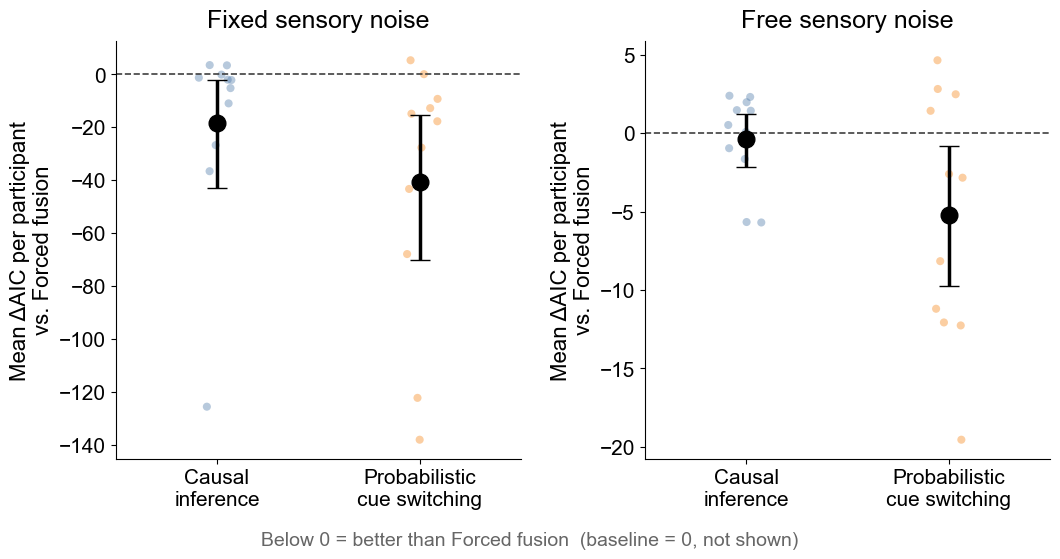

Participant bootstrap (10,000 iterations, 95% CI). Headline = mean ΔAIC per participant vs Forced fusion.

         fit_source                   modelType mean ΔAIC vs base [95% CI] sum ΔAIC vs base [95% CI]  centered AIC [95% CI] sum centered AIC [95% CI]
Fixed sensory noise               Forced fusion       +0.00 [+0.00, +0.00]         +0.0 [+0.0, +0.0] +19.75 [+7.48, +36.06]    +217.3 [+82.3, +396.7]
Fixed sensory noise            Causal inference     -18.50 [-43.00, -2.26]    -203.5 [-473.0, -24.9] +1.25 [-10.28, +13.13]    +13.8 [-113.1, +144.4]
Fixed sensory noise Probabilistic cue switching    -40.75 [-70.06, -15.32]   -448.3 [-770.7, -168.6] -21.00 [-37.56, -7.16]    -231.0 [-413.1, -78.8]
 Free sensory noise               Forced fusion       +0.00 [+0.00, +0.00]         +0.0 [+0.0, +0.0]   +1.85 [+0.15, +3.57]       +20.3 [+1.6, +39.2]
 Free sensory noise            Causal inference       -0.34 [-2.13, +1.21]       -3.8 [-23.5, +13.3]   +1.51 [-0.02, +3.22]       +16.6 [-0.2, 

In [16]:
PANEL_SPECS = [
    {'label': 'Fixed sensory noise', 'df': df_unimodal},
    {'label': 'Free sensory noise', 'df': df_free},
]

FONT_SIZE = 18
BOOTSTRAP_ITERATIONS = 10000
BOOTSTRAP_CI = (2.5, 97.5)

# Stable per-model colours (used for the per-participant point clouds).
MODEL_COLORS = {
    'Forced fusion': '#7F7F7F',
    'Causal inference': '#4C78A8',
    'Probabilistic cue switching': '#F58518',
}


def wrap_label(text, max_chars=15):
    words = text.split()
    if not words:
        return text
    lines = [words[0]]
    for word in words[1:]:
        candidate = f"{lines[-1]} {word}"
        if len(candidate) <= max_chars:
            lines[-1] = candidate
        else:
            lines.append(word)
    return "\n".join(lines)


def raw_aic_matrix(df_results):
    """AIC values as a (participants x models) matrix in MODEL_ORDER."""
    matrix = df_results.pivot_table(index='participantID', columns='modelType', values='AIC', aggfunc='min')
    participant_order = sorted(matrix.index)
    model_order = [m for m in MODEL_ORDER if m in matrix.columns]
    return matrix.reindex(index=participant_order, columns=model_order)


def delta_aic_matrix(df_results, base_model=BASE_MODEL):
    """Per-participant ΔAIC vs. base_model (base column identically 0)."""
    raw = raw_aic_matrix(df_results)
    if base_model not in raw.columns:
        raise ValueError(f"Missing {base_model!r} column.")
    return raw.sub(raw[base_model], axis=0)


def centered_aic_matrix(df_results):
    """AIC centered on each participant's across-model mean (rows sum to 0)."""
    raw = raw_aic_matrix(df_results)
    return raw.sub(raw.mean(axis=1), axis=0)


def bootstrap_aic(df_results, base_model=BASE_MODEL, n_boot=BOOTSTRAP_ITERATIONS,
                  ci=BOOTSTRAP_CI, seed=0):
    """Participant bootstrap of AIC, computed from the *same* resamples.

    Returns, per model:
      - mean_deltaAIC    : mean per-participant ΔAIC vs. base_model (base == 0).
                           Random-effects-style effect size; the headline statistic.
      - sum_deltaAIC     : summed ΔAIC vs. base_model (pooled fixed-effects statistic).
      - centered_AIC     : mean of (AIC − participant across-model mean); free
                           reference so every model gets a CI.
      - sum_centered_AIC : summed (AIC − participant across-model mean).
    All references remove between-participant level via within-participant pairing;
    the bootstrap only adds CIs.
    """
    raw = raw_aic_matrix(df_results)
    models = list(raw.columns)
    base = models.index(base_model)

    centered = raw.to_numpy(float) - raw.to_numpy(float).mean(axis=1, keepdims=True)
    delta = raw.to_numpy(float) - raw.to_numpy(float)[:, [base]]
    n_participants = raw.shape[0]

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n_participants, size=(n_boot, n_participants))
    boot_centered = centered[idx].mean(axis=1)          # (n_boot, K)
    boot_centered_sum = centered[idx].sum(axis=1)
    boot_delta_mean = delta[idx].mean(axis=1)
    boot_delta_sum = delta[idx].sum(axis=1)

    rows = []
    for k, model in enumerate(models):
        c_lo, c_hi = np.percentile(boot_centered[:, k], ci)
        sc_lo, sc_hi = np.percentile(boot_centered_sum[:, k], ci)
        dm_lo, dm_hi = np.percentile(boot_delta_mean[:, k], ci)
        ds_lo, ds_hi = np.percentile(boot_delta_sum[:, k], ci)
        rows.append({
            'modelType': model,
            'mean_deltaAIC': delta[:, k].mean(),
            'mean_ci_low': dm_lo, 'mean_ci_high': dm_hi,
            'sum_deltaAIC': delta[:, k].sum(),
            'sum_ci_low': ds_lo, 'sum_ci_high': ds_hi,
            'centered_AIC': centered[:, k].mean(),
            'centered_ci_low': c_lo, 'centered_ci_high': c_hi,
            'sum_centered_AIC': centered[:, k].sum(),
            'sum_centered_ci_low': sc_lo, 'sum_centered_ci_high': sc_hi,
            'n_participants': n_participants,
        })
    return pd.DataFrame(rows)


def plot_mean_delta_aic(base_model=BASE_MODEL, save_path='meanDeltaAIC_threeModels.pdf'):
    """HEADLINE figure: bootstrapped mean per-participant ΔAIC vs. the baseline model.

    The baseline is the reference (identically 0) and is omitted from the axis. Each
    remaining model shows the mean per-participant ΔAIC with a 95% participant-
    bootstrap CI, overlaid with the individual-participant ΔAIC values. Below 0 =
    better than baseline. This is a random-effects-style effect size and does not
    scale with N (unlike the summed ΔAIC supplement).
    """
    non_base = [m for m in MODEL_ORDER if m != base_model]
    jitter_rng = np.random.default_rng(7)
    summaries = []

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.6), sharey=False)
    for i, (ax, spec) in enumerate(zip(axes, PANEL_SPECS)):
        summary = bootstrap_aic(spec['df'], base_model=base_model, seed=1 + i)
        summary['fit_source'] = spec['label']
        summaries.append(summary)

        s = summary.set_index('modelType').reindex(non_base)
        x = np.arange(len(non_base))
        delta = delta_aic_matrix(spec['df'], base_model=base_model).reindex(columns=non_base)

        # individual-participant ΔAIC point cloud
        for xi, model in zip(x, non_base):
            pts = delta[model].to_numpy(dtype=float)
            jitter = jitter_rng.uniform(-0.09, 0.09, size=pts.size)
            ax.scatter(np.full(pts.size, xi) + jitter, pts, s=34,
                       color=MODEL_COLORS[model], alpha=0.40, edgecolor='none', zorder=2)

        # bootstrapped mean +/- 95% CI
        y = s['mean_deltaAIC'].to_numpy(dtype=float)
        yerr = np.vstack([
            y - s['mean_ci_low'].to_numpy(dtype=float),
            s['mean_ci_high'].to_numpy(dtype=float) - y,
        ])
        ax.errorbar(x, y, yerr=yerr, fmt='o', markersize=12, capsize=7,
                    linewidth=2.5, color='black', zorder=3)

        ax.axhline(0, color='0.25', linewidth=1.2, linestyle='--')
        ax.set_title(spec['label'], fontsize=FONT_SIZE, pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels([wrap_label(m) for m in non_base], fontsize=FONT_SIZE - 3)
        ax.set_xlim(-0.5, len(non_base) - 0.5)
        ax.tick_params(axis='y', labelsize=FONT_SIZE - 3)
        ax.set_ylabel(f'Mean ΔAIC per participant\nvs. {base_model}', fontsize=FONT_SIZE - 2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.text(0.5, -0.01, f'Below 0 = better than {base_model}  (baseline = 0, not shown)',
             ha='center', fontsize=FONT_SIZE - 4, color='0.4')
    fig.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()

    return pd.concat(summaries, ignore_index=True)


def format_bootstrap_table(summary_df, base_model=BASE_MODEL):
    """Human-readable table: ΔAIC-vs-base (mean and sum) + centered AIC, with CIs."""
    out = summary_df.copy()
    out['mean ΔAIC vs base [95% CI]'] = out.apply(
        lambda r: f"{r['mean_deltaAIC']:+.2f} [{r['mean_ci_low']:+.2f}, {r['mean_ci_high']:+.2f}]", axis=1)
    out['sum ΔAIC vs base [95% CI]'] = out.apply(
        lambda r: f"{r['sum_deltaAIC']:+.1f} [{r['sum_ci_low']:+.1f}, {r['sum_ci_high']:+.1f}]", axis=1)
    out['centered AIC [95% CI]'] = out.apply(
        lambda r: f"{r['centered_AIC']:+.2f} [{r['centered_ci_low']:+.2f}, {r['centered_ci_high']:+.2f}]", axis=1)
    out['sum centered AIC [95% CI]'] = out.apply(
        lambda r: f"{r['sum_centered_AIC']:+.1f} [{r['sum_centered_ci_low']:+.1f}, {r['sum_centered_ci_high']:+.1f}]", axis=1)
    out = out[['fit_source', 'modelType', 'mean ΔAIC vs base [95% CI]', 'sum ΔAIC vs base [95% CI]',
               'centered AIC [95% CI]', 'sum centered AIC [95% CI]']]
    out['modelType'] = pd.Categorical(out['modelType'], categories=MODEL_ORDER, ordered=True)
    return out.sort_values(['fit_source', 'modelType']).reset_index(drop=True)


aic_bootstrap = plot_mean_delta_aic()
bootstrap_summary_table = format_bootstrap_table(aic_bootstrap)

print(f'Participant bootstrap ({BOOTSTRAP_ITERATIONS:,} iterations, '
      f'{BOOTSTRAP_CI[1] - BOOTSTRAP_CI[0]:.0f}% CI). Headline = mean ΔAIC per '
      f'participant vs {BASE_MODEL}.\n')
print(bootstrap_summary_table.to_string(index=False))


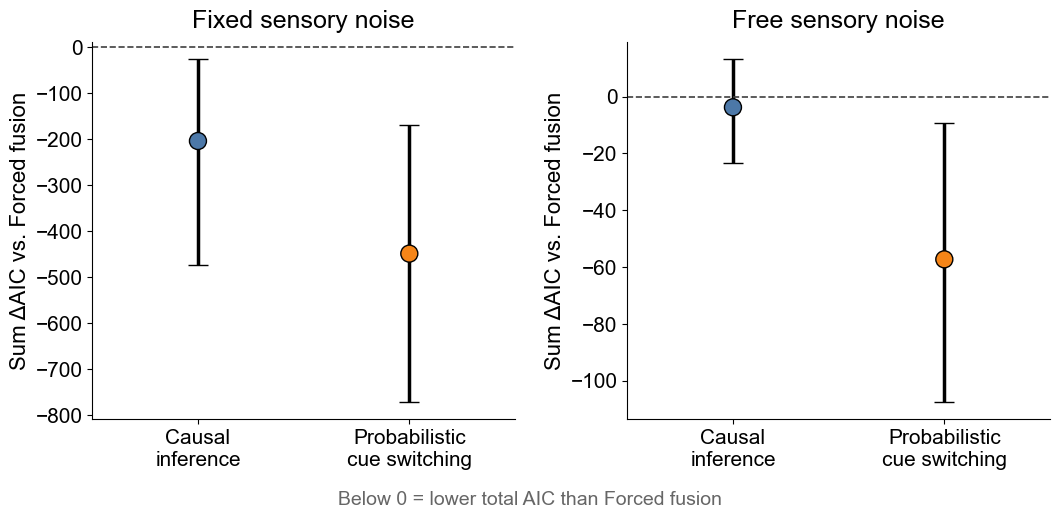

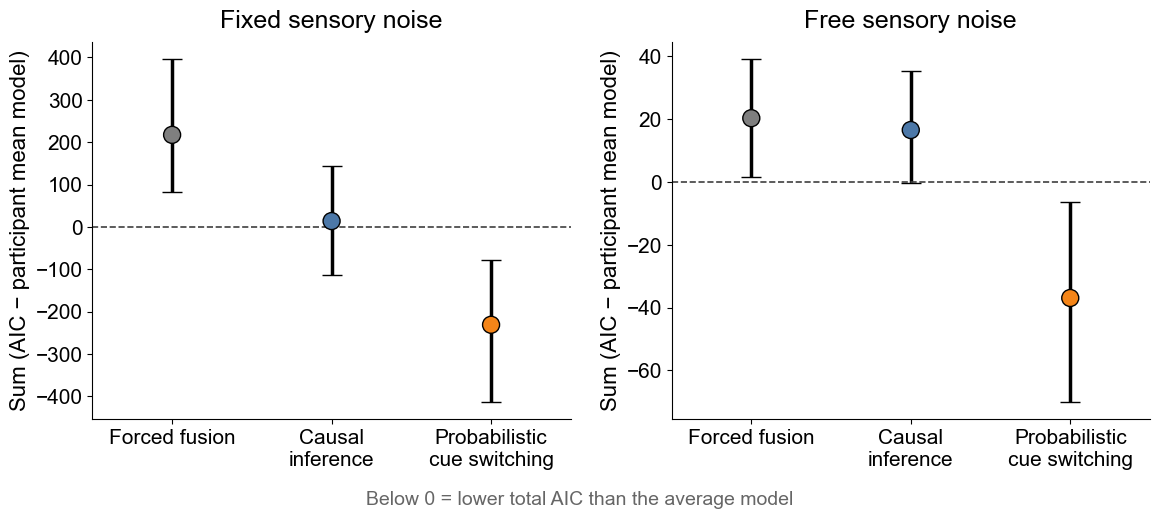

In [17]:
def plot_sum_delta_aic(summary_df, base_model=BASE_MODEL, save_path='sumDeltaAIC_threeModels.pdf'):
    """Fixed-effects companion: summed ΔAIC vs. base with participant-bootstrap CIs.

    Σ_i AIC_i = 2Σk − 2Σ logL is the pooled fixed-effects criterion. The baseline
    model is the reference (identically 0) and is omitted from the axis; below 0 =
    lower total AIC than baseline. Note the wide CIs: the *sum* scales with N and is
    dominated by a couple of high-leverage participants (hh, ip), so each resample's
    count of them swings the total — see the mean / centered figures for the readable
    per-participant version. Reuses the same bootstrap resamples as those figures.
    """
    non_base = [m for m in MODEL_ORDER if m != base_model]
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharey=False)
    for ax, spec in zip(axes, PANEL_SPECS):
        s = (summary_df[summary_df['fit_source'] == spec['label']]
             .set_index('modelType').reindex(non_base))
        x = np.arange(len(non_base))
        y = s['sum_deltaAIC'].to_numpy(float)
        yerr = np.vstack([y - s['sum_ci_low'].to_numpy(float),
                          s['sum_ci_high'].to_numpy(float) - y])

        ax.errorbar(x, y, yerr=yerr, fmt='none', ecolor='black',
                    capsize=7, linewidth=2.5, zorder=2)
        ax.scatter(x, y, s=150, c=[MODEL_COLORS[m] for m in non_base],
                   edgecolor='black', linewidth=1.0, zorder=3)
        ax.axhline(0, color='0.25', linewidth=1.2, linestyle='--')
        ax.set_title(spec['label'], fontsize=FONT_SIZE, pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels([wrap_label(m) for m in non_base], fontsize=FONT_SIZE - 3)
        ax.set_xlim(-0.5, len(non_base) - 0.5)
        ax.tick_params(axis='y', labelsize=FONT_SIZE - 3)
        ax.set_ylabel(f'Sum ΔAIC vs. {base_model}', fontsize=FONT_SIZE - 2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.text(0.5, -0.01, f'Below 0 = lower total AIC than {base_model}',
             ha='center', fontsize=FONT_SIZE - 4, color='0.4')
    fig.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()


def plot_sum_centered_aic(summary_df, save_path='sumDeltaAIC_centered_threeModels.pdf'):
    """Free-baseline sum: summed (AIC − participant across-model mean) per model.

    Same fixed-effects 'sum' framing as plot_sum_delta_aic, but referenced to each
    participant's average model instead of one baseline. No model is pinned to 0, so
    all three carry a bootstrap CI; the three sums add to 0. Lower = better.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=False)
    for ax, spec in zip(axes, PANEL_SPECS):
        s = (summary_df[summary_df['fit_source'] == spec['label']]
             .set_index('modelType').reindex(MODEL_ORDER))
        x = np.arange(len(MODEL_ORDER))
        y = s['sum_centered_AIC'].to_numpy(float)
        yerr = np.vstack([y - s['sum_centered_ci_low'].to_numpy(float),
                          s['sum_centered_ci_high'].to_numpy(float) - y])

        ax.errorbar(x, y, yerr=yerr, fmt='none', ecolor='black',
                    capsize=7, linewidth=2.5, zorder=2)
        ax.scatter(x, y, s=150, c=[MODEL_COLORS[m] for m in MODEL_ORDER],
                   edgecolor='black', linewidth=1.0, zorder=3)
        ax.axhline(0, color='0.25', linewidth=1.2, linestyle='--')
        ax.set_title(spec['label'], fontsize=FONT_SIZE, pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels([wrap_label(m) for m in MODEL_ORDER], fontsize=FONT_SIZE - 3)
        ax.set_xlim(-0.5, len(MODEL_ORDER) - 0.5)
        #ax.set_yticks(np.arange(-400, 400, 200))
        ax.tick_params(axis='y', labelsize=FONT_SIZE - 3)
        ax.set_ylabel('Sum (AIC − participant mean model)', fontsize=FONT_SIZE - 2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.text(0.5, -0.01, 'Below 0 = lower total AIC than the average model',
             ha='center', fontsize=FONT_SIZE - 4, color='0.4')
    fig.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()


plot_sum_delta_aic(aic_bootstrap)
plot_sum_centered_aic(aic_bootstrap)


## 4b. Monte-Carlo noise floor of per-participant AIC

The per-participant AIC carries Monte-Carlo noise from the simulated likelihood
(`nSimul = 2000`). To check this does not undermine the ΔAIC comparisons, each
saved fit's log-likelihood is **re-evaluated at its fitted parameters under 20 RNG
seeds**, and we take the SD of the resulting AIC as the noise floor. Each
reconstruction is validated against the saved logLik (all 66 fits reproduce it
within MC noise). Computed by `compute_aic_noise_floor.py` (cached to
`aic_noise_floor_seeds.json`).

In [18]:
# Monte-Carlo noise floor: SD of per-participant AIC across RNG seeds at the fitted
# params. Reads the cache if present; otherwise recomputes (~minutes).
from compute_aic_noise_floor import get_noise_floor

nf = get_noise_floor(verbose=False)          # per participant x model x fit_source
assert nf['valid'].all(), "Some reconstructions did not reproduce the saved logLik."

# --- single-model noise floor per fit source ---
floor = (nf.groupby('fit_source')
           .agg(n_participants=('participantID', 'nunique'),
                AIC_sd_median=('AIC_sd', 'median'),
                AIC_sd_max=('AIC_sd', 'max'))
           .reset_index())
# A ΔAIC between two independently-fit models carries ~sqrt(2)x a single model's MC SD.
floor['dAIC_floor_participant'] = np.sqrt(2) * floor['AIC_sd_median']
# The GROUP mean over N participants averages that MC noise down by sqrt(N).
floor['dAIC_floor_groupmean'] = floor['dAIC_floor_participant'] / np.sqrt(floor['n_participants'])

print('Monte-Carlo AIC noise floor (20 seeds, nSimul=2000):\n')
print(floor.round(2).to_string(index=False))

# --- compare the headline mean ΔAIC vs the floor, per non-base model ---
nb_models = [m for m in MODEL_ORDER if m != BASE_MODEL]
cmp = (aic_bootstrap[aic_bootstrap['modelType'].isin(nb_models)]
       [['fit_source', 'modelType', 'mean_deltaAIC', 'mean_ci_low', 'mean_ci_high']]
       .merge(floor[['fit_source', 'dAIC_floor_participant', 'dAIC_floor_groupmean']],
              on='fit_source', how='left'))

def _verdict(r):
    crosses0 = (r['mean_ci_low'] <= 0 <= r['mean_ci_high'])
    big = abs(r['mean_deltaAIC']) > 3 * r['dAIC_floor_groupmean']
    if crosses0:
        within = abs(r['mean_deltaAIC']) < r['dAIC_floor_participant']
        return 'null (CI crosses 0)' + ('; per-subj effect < MC floor' if within else '')
    return 'robust (effect >> MC floor)' if big else 'fragile (effect ~ MC floor)'

cmp['verdict'] = cmp.apply(_verdict, axis=1)
cmp['mean ΔAIC/participant [95% CI]'] = cmp.apply(
    lambda r: f"{r['mean_deltaAIC']:+.2f} [{r['mean_ci_low']:+.2f}, {r['mean_ci_high']:+.2f}]", axis=1)
cmp['MC floor (per-subj / group-mean)'] = cmp.apply(
    lambda r: f"{r['dAIC_floor_participant']:.2f} / {r['dAIC_floor_groupmean']:.2f}", axis=1)

print('\nΔAIC vs the Monte-Carlo noise floor:\n')
print(cmp[['fit_source', 'modelType', 'mean ΔAIC/participant [95% CI]',
           'MC floor (per-subj / group-mean)', 'verdict']].to_string(index=False))

print('\nReading:')
print('• Fixed sensory noise: ΔAIC ~ -40/participant is ~25x the per-subject MC floor')
print('  (~2 AIC) -> the model preference is real, not Monte-Carlo noise.')
print('• Free sensory noise: per-participant ΔAIC (~2) is within the per-subject MC')
print('  floor, so INDIVIDUAL free-noise classifications are unreliable. At the group')
print('  level the MC noise averages down (group-mean floor < 1 AIC), so the free-noise')
print('  null is driven by BETWEEN-participant variability (bootstrap CI crosses 0), not')
print('  by Monte-Carlo noise.')


Monte-Carlo AIC noise floor (20 seeds, nSimul=2000):

         fit_source  n_participants  AIC_sd_median  AIC_sd_max  dAIC_floor_participant  dAIC_floor_groupmean
Fixed sensory noise              11           1.62        2.42                    2.29                  0.69
 Free sensory noise              11           1.91        2.85                    2.70                  0.81

ΔAIC vs the Monte-Carlo noise floor:

         fit_source                   modelType mean ΔAIC/participant [95% CI] MC floor (per-subj / group-mean)                                         verdict
Fixed sensory noise            Causal inference         -18.50 [-43.00, -2.26]                      2.29 / 0.69                     robust (effect >> MC floor)
Fixed sensory noise Probabilistic cue switching        -40.75 [-70.06, -15.32]                      2.29 / 0.69                     robust (effect >> MC floor)
 Free sensory noise            Causal inference           -0.34 [-2.13, +1.21]                      

## 5. ΔAIC heatmap comparison table


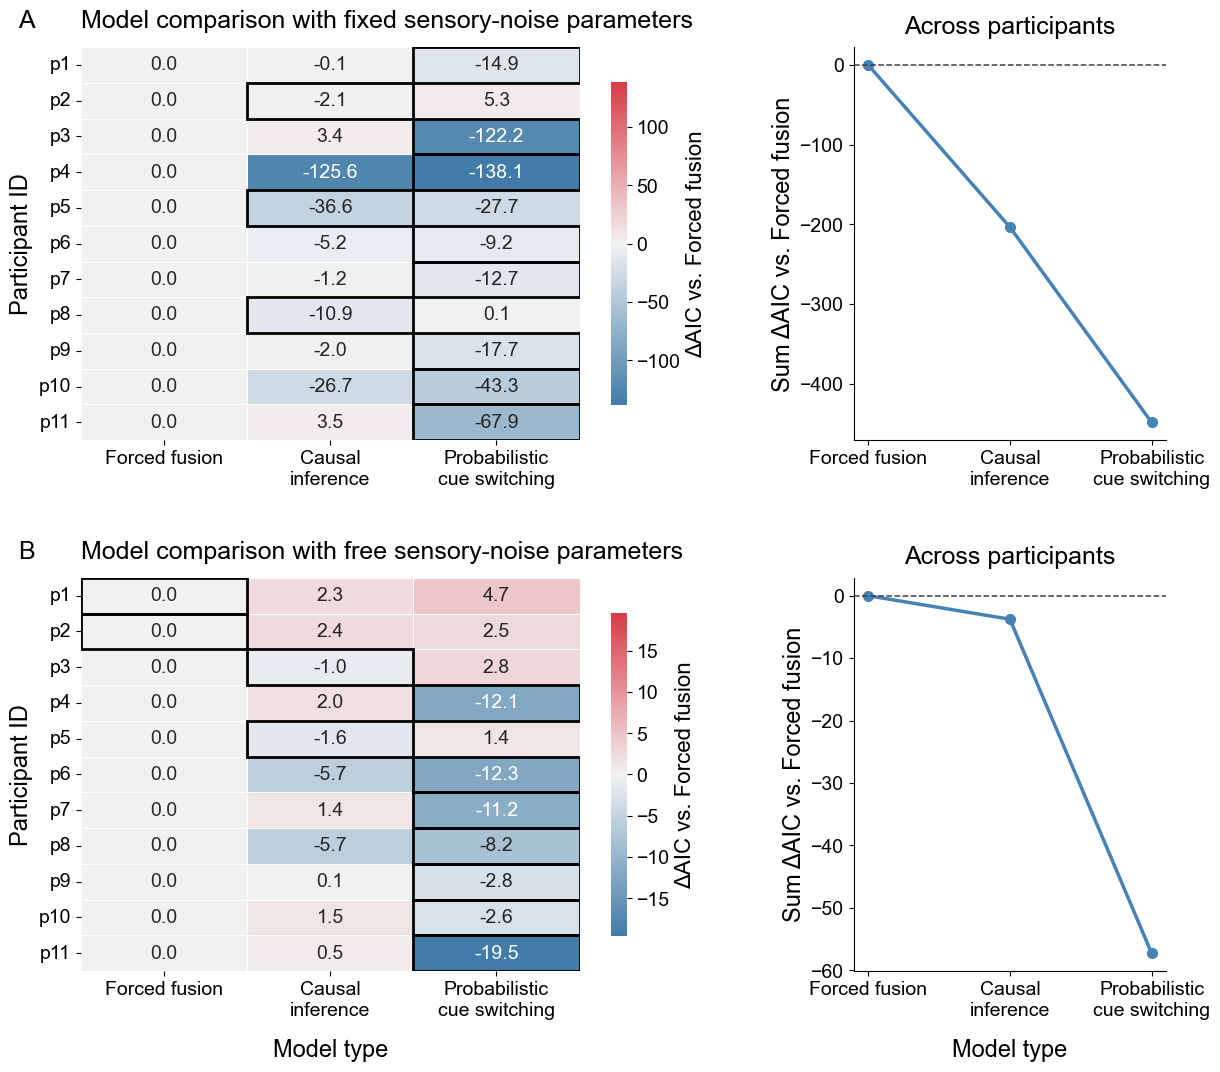

In [19]:
def add_base_model_deltas(df_results, base_model=BASE_MODEL):
    df = df_results.copy()
    base = (df.loc[df['modelType'] == base_model, ['participantID', 'AIC', 'BIC']]
              .sort_values(['participantID', 'AIC'])
              .drop_duplicates(subset=['participantID'], keep='first')
              .rename(
        columns={'AIC': 'base_AIC', 'BIC': 'base_BIC'}
    ))
    missing_base = sorted(set(df['participantID']) - set(base['participantID']))
    if missing_base:
        raise ValueError(f"Missing {base_model!r} rows for participants: {missing_base}")

    df = df.merge(base, on='participantID', how='left', validate='many_to_one')
    df['deltaAIC'] = df['AIC'] - df['base_AIC']
    df['deltaBIC'] = df['BIC'] - df['base_BIC']
    return df


def comparison_table(df_results, base_model=BASE_MODEL):
    df = add_base_model_deltas(df_results, base_model=base_model)
    pivot = df.pivot_table(index='participantID', columns='modelType',
                            values=['logLikelihood', 'AIC', 'deltaAIC', 'BIC', 'deltaBIC'])
    pivot = pivot.reindex(columns=pd.MultiIndex.from_product(
        [['logLikelihood', 'AIC', 'deltaAIC', 'BIC', 'deltaBIC'], MODEL_ORDER]
    ))
    return pivot


def delta_aic_table(df_results, base_model=BASE_MODEL):
    df = add_base_model_deltas(df_results, base_model=base_model)
    table = df.pivot_table(index='participantID', columns='modelType', values='deltaAIC', aggfunc='min')
    table = table.reindex(index=sorted(table.index), columns=MODEL_ORDER)
    return table


def sum_delta_aic(df_results, base_model=BASE_MODEL):
    summary = delta_aic_table(df_results, base_model=base_model).sum(axis=0)
    return summary.rename('sum_deltaAIC').to_frame()


def draw_delta_aic_heatmap_row(fig, axes, delta_table, panel_label, panel_title, base_model=BASE_MODEL, show_xlabels=True):
    ax_heat, ax_sum = axes
    delta_table = delta_table.reindex(columns=[m for m in MODEL_ORDER if m in delta_table.columns])

    finite = delta_table.to_numpy(dtype=float)
    finite = finite[np.isfinite(finite)]
    absmax = max(float(np.abs(finite).max()) if finite.size else 1.0, 1.0)

    heatmap = sns.heatmap(
        delta_table,
        annot=True,
        fmt='.1f',
        cmap=sns.diverging_palette(240, 10, as_cmap=True),
        center=0,
        vmin=-absmax,
        vmax=absmax,
        linewidths=0.5,
        linecolor='white',
        ax=ax_heat,
        cbar=True,
        cbar_kws={'label': f'ΔAIC vs. {base_model}', 'shrink': 0.82},
        annot_kws={'fontsize': FONT_SIZE - 4},
    )
    cbar = heatmap.collections[0].colorbar
    cbar.set_label(f'ΔAIC vs. {base_model}', fontsize=FONT_SIZE - 2)
    cbar.ax.tick_params(labelsize=FONT_SIZE - 4)

    ax_heat.set_xlabel('Model type' if show_xlabels else '', fontsize=FONT_SIZE - 1, labelpad=14)
    ax_heat.set_ylabel('Participant ID', fontsize=FONT_SIZE - 1)
    ax_heat.set_xticklabels([wrap_label(tick.get_text()) for tick in ax_heat.get_xticklabels()],
                            rotation=0, ha='center', fontsize=FONT_SIZE - 4)
    ax_heat.set_yticklabels([f'p{i}' for i, _ in enumerate(delta_table.index, start=1)],
                            rotation=0, fontsize=FONT_SIZE - 4)

    # Box the best-fitting model (lowest AIC, i.e. smallest ΔAIC) for each
    # participant — not always the baseline column.
    values = delta_table.to_numpy(dtype=float)
    for row_idx in range(values.shape[0]):
        best_col = int(np.nanargmin(values[row_idx]))
        ax_heat.add_patch(plt.Rectangle((best_col, row_idx), 1, 1, fill=False,
                                        edgecolor='black', lw=2.0))

    model_sums = delta_table.sum(axis=0).reindex(delta_table.columns)
    ax_sum.plot(range(len(model_sums)), model_sums.values, marker='o', linestyle='-',
                linewidth=2.5, markersize=7, color='steelblue')
    ax_sum.axhline(0, color='0.25', linewidth=1.1, linestyle='--')
    ax_sum.set_xticks(range(len(model_sums)))
    ax_sum.set_xticklabels([wrap_label(model) for model in model_sums.index],
                           rotation=0, ha='center', fontsize=FONT_SIZE - 4)
    ax_sum.set_xlabel('Model type' if show_xlabels else '', fontsize=FONT_SIZE - 1, labelpad=14)
    ax_sum.set_ylabel(f'Sum ΔAIC vs. {base_model}', fontsize=FONT_SIZE - 1)
    ax_sum.set_title('Across participants', fontsize=FONT_SIZE, pad=10)
    ax_sum.tick_params(axis='y', labelsize=FONT_SIZE - 4)
    ax_sum.spines['top'].set_visible(False)
    ax_sum.spines['right'].set_visible(False)

    bbox = ax_heat.get_position()
    title_y = bbox.y1 + 0.012
    fig.text(bbox.x0 - 0.045, title_y, panel_label, fontsize=FONT_SIZE, ha='left', va='bottom')
    fig.text(bbox.x0, title_y, panel_title, fontsize=FONT_SIZE, ha='left', va='bottom')


def plot_three_model_delta_aic_heatmap(base_model=BASE_MODEL, save_path='modelComparison_threeModels_heatmap.pdf'):
    specs = [
        {'panel_label': 'A', 'title': 'Model comparison with fixed sensory-noise parameters', 'table': delta_aic_table(df_unimodal, base_model=base_model)},
        {'panel_label': 'B', 'title': 'Model comparison with free sensory-noise parameters', 'table': delta_aic_table(df_free, base_model=base_model)},
    ]

    fig, axes = plt.subplots(
        2, 2, figsize=(14, 12),
        gridspec_kw={'width_ratios': [2.4, 1.2], 'hspace': 0.35, 'wspace': 0.32},
    )
    fig.patch.set_facecolor('white')

    for row_idx, spec in enumerate(specs):
        draw_delta_aic_heatmap_row(
            fig, axes[row_idx], spec['table'],
            panel_label=spec['panel_label'], panel_title=spec['title'],
            base_model=base_model, show_xlabels=(row_idx == len(specs) - 1),
        )

    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()
    return specs


free_table = comparison_table(df_free)
uni_table = comparison_table(df_unimodal)
free_delta_table = delta_aic_table(df_free)
uni_delta_table = delta_aic_table(df_unimodal)
free_sum_delta_aic = sum_delta_aic(df_free)
uni_sum_delta_aic = sum_delta_aic(df_unimodal)
comparison_heatmap_datasets = plot_three_model_delta_aic_heatmap()


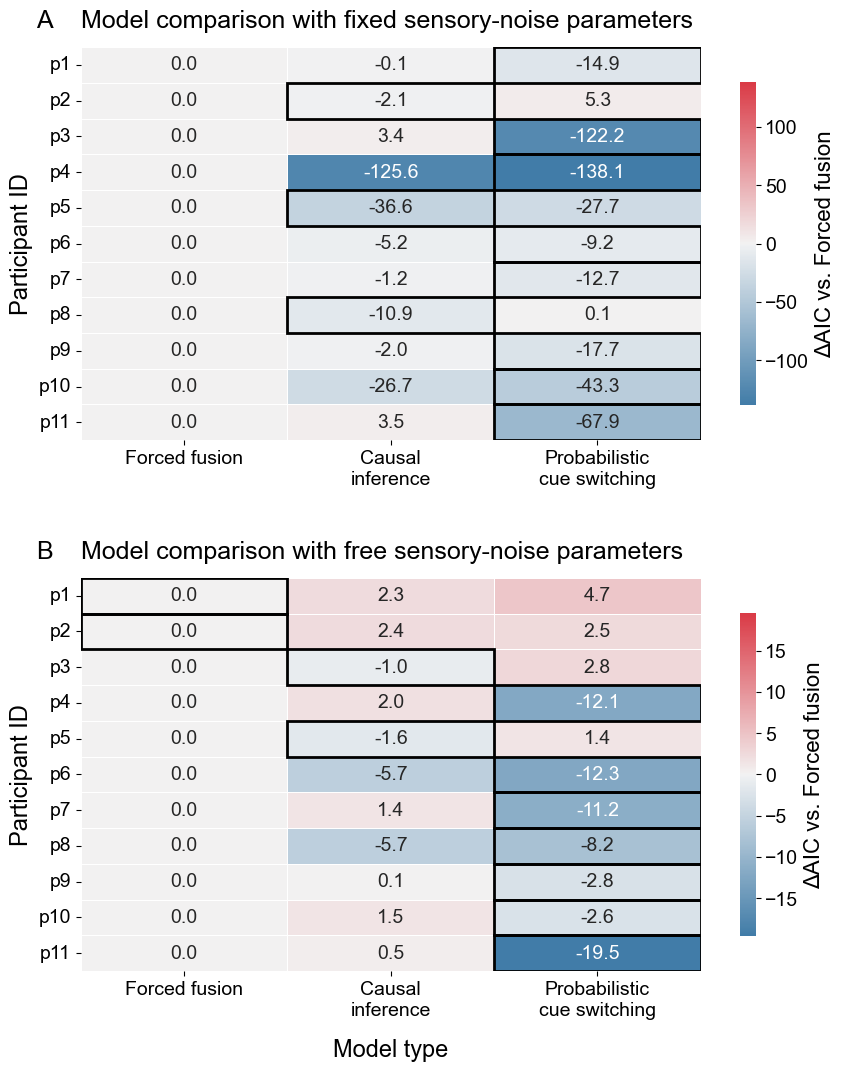

In [20]:
def add_base_model_deltas(df_results, base_model=BASE_MODEL):
    df = df_results.copy()
    base = (df.loc[df['modelType'] == base_model, ['participantID', 'AIC', 'BIC']]
              .sort_values(['participantID', 'AIC'])
              .drop_duplicates(subset=['participantID'], keep='first')
              .rename(
        columns={'AIC': 'base_AIC', 'BIC': 'base_BIC'}
    ))
    missing_base = sorted(set(df['participantID']) - set(base['participantID']))
    if missing_base:
        raise ValueError(f"Missing {base_model!r} rows for participants: {missing_base}")

    df = df.merge(base, on='participantID', how='left', validate='many_to_one')
    df['deltaAIC'] = df['AIC'] - df['base_AIC']
    df['deltaBIC'] = df['BIC'] - df['base_BIC']
    return df


def comparison_table(df_results, base_model=BASE_MODEL):
    df = add_base_model_deltas(df_results, base_model=base_model)
    pivot = df.pivot_table(index='participantID', columns='modelType',
                            values=['logLikelihood', 'AIC', 'deltaAIC', 'BIC', 'deltaBIC'])
    pivot = pivot.reindex(columns=pd.MultiIndex.from_product(
        [['logLikelihood', 'AIC', 'deltaAIC', 'BIC', 'deltaBIC'], MODEL_ORDER]
    ))
    return pivot


def delta_aic_table(df_results, base_model=BASE_MODEL):
    df = add_base_model_deltas(df_results, base_model=base_model)
    table = df.pivot_table(index='participantID', columns='modelType', values='deltaAIC', aggfunc='min')
    table = table.reindex(index=sorted(table.index), columns=MODEL_ORDER)
    return table


def sum_delta_aic(df_results, base_model=BASE_MODEL):
    summary = delta_aic_table(df_results, base_model=base_model).sum(axis=0)
    return summary.rename('sum_deltaAIC').to_frame()


def draw_delta_aic_heatmap_row(fig, axes, delta_table, panel_label, panel_title, base_model=BASE_MODEL, show_xlabels=True):
    # axes can be either a single Axes (only heatmap) or a (heatmap, sum) tuple
    if isinstance(axes, (list, tuple, np.ndarray)):
        ax_heat, ax_sum = axes
        do_sum = True
    else:
        ax_heat = axes
        ax_sum = None
        do_sum = False

    delta_table = delta_table.reindex(columns=[m for m in MODEL_ORDER if m in delta_table.columns])

    finite = delta_table.to_numpy(dtype=float)
    finite = finite[np.isfinite(finite)]
    absmax = max(float(np.abs(finite).max()) if finite.size else 1.0, 1.0)

    heatmap = sns.heatmap(
        delta_table,
        annot=True,
        fmt='.1f',
        cmap=sns.diverging_palette(240, 10, as_cmap=True),
        center=0,
        vmin=-absmax,
        vmax=absmax,
        linewidths=0.5,
        linecolor='white',
        ax=ax_heat,
        cbar=True,
        cbar_kws={'label': f'ΔAIC vs. {base_model}', 'shrink': 0.82},
        annot_kws={'fontsize': FONT_SIZE - 4},
    )
    cbar = heatmap.collections[0].colorbar
    cbar.set_label(f'ΔAIC vs. {base_model}', fontsize=FONT_SIZE - 2)
    cbar.ax.tick_params(labelsize=FONT_SIZE - 4)

    ax_heat.set_xlabel('Model type' if show_xlabels else '', fontsize=FONT_SIZE - 1, labelpad=14)
    ax_heat.set_ylabel('Participant ID', fontsize=FONT_SIZE - 1)
    ax_heat.set_xticklabels([wrap_label(tick.get_text()) for tick in ax_heat.get_xticklabels()],
                            rotation=0, ha='center', fontsize=FONT_SIZE - 4)
    ax_heat.set_yticklabels([f'p{i}' for i, _ in enumerate(delta_table.index, start=1)],
                            rotation=0, fontsize=FONT_SIZE - 4)

    # Box the best-fitting model (lowest AIC, i.e. smallest ΔAIC) for each participant
    values = delta_table.to_numpy(dtype=float)
    for row_idx in range(values.shape[0]):
        best_col = int(np.nanargmin(values[row_idx]))
        ax_heat.add_patch(plt.Rectangle((best_col, row_idx), 1, 1, fill=False,
                                        edgecolor='black', lw=2.0))

    if do_sum:
        model_sums = delta_table.sum(axis=0).reindex(delta_table.columns)
        ax_sum.plot(range(len(model_sums)), model_sums.values, marker='o', linestyle='-',
                    linewidth=2.5, markersize=7, color='steelblue')
        ax_sum.axhline(0, color='0.25', linewidth=1.1, linestyle='--')
        ax_sum.set_xticks(range(len(model_sums)))
        ax_sum.set_xticklabels([wrap_label(model) for model in model_sums.index],
                               rotation=0, ha='center', fontsize=FONT_SIZE - 4)
        ax_sum.set_xlabel('Model type' if show_xlabels else '', fontsize=FONT_SIZE - 1, labelpad=14)
        ax_sum.set_ylabel(f'Sum ΔAIC vs. {base_model}', fontsize=FONT_SIZE - 1)
        ax_sum.set_title('Across participants', fontsize=FONT_SIZE, pad=10)
        ax_sum.tick_params(axis='y', labelsize=FONT_SIZE - 4)
        ax_sum.spines['top'].set_visible(False)
        ax_sum.spines['right'].set_visible(False)

    bbox = ax_heat.get_position()
    title_y = bbox.y1 + 0.012
    fig.text(bbox.x0 - 0.045, title_y, panel_label, fontsize=FONT_SIZE, ha='left', va='bottom')
    fig.text(bbox.x0, title_y, panel_title, fontsize=FONT_SIZE, ha='left', va='bottom')


def plot_three_model_delta_aic_heatmap(base_model=BASE_MODEL, save_path='modelComparison_threeModels_heatmap.pdf'):
    specs = [
        {'panel_label': 'A', 'title': 'Model comparison with fixed sensory-noise parameters', 'table': delta_aic_table(df_unimodal, base_model=base_model)},
        {'panel_label': 'B', 'title': 'Model comparison with free sensory-noise parameters', 'table': delta_aic_table(df_free, base_model=base_model)},
    ]

    fig, axes = plt.subplots(
        2, 1, figsize=(10, 12),
        gridspec_kw={'hspace': 0.35},
    )
    fig.patch.set_facecolor('white')

    for row_idx, spec in enumerate(specs):
        draw_delta_aic_heatmap_row(
            fig, axes[row_idx], spec['table'],
            panel_label=spec['panel_label'], panel_title=spec['title'],
            base_model=base_model, show_xlabels=(row_idx == len(specs) - 1),
        )

    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()
    return specs


free_table = comparison_table(df_free)
uni_table = comparison_table(df_unimodal)
free_delta_table = delta_aic_table(df_free)
uni_delta_table = delta_aic_table(df_unimodal)
free_sum_delta_aic = sum_delta_aic(df_free)
uni_sum_delta_aic = sum_delta_aic(df_unimodal)
comparison_heatmap_datasets = plot_three_model_delta_aic_heatmap()


## 6. Random-effects Bayesian model selection

Variational Bayes (Stephan et al., 2009) and protected exceedance probabilities (Rigoux et al., 2014), using −½ AIC as the log model evidence.

In [21]:
def build_log_evidence_matrix(df_results, models_ordered):
    participants = sorted(df_results['participantID'].unique())
    K = len(models_ordered)
    N = len(participants)
    L = np.full((N, K), -np.inf)
    for i, pid in enumerate(participants):
        for j, mod in enumerate(models_ordered):
            row = df_results[(df_results['participantID'] == pid) & (df_results['modelType'] == mod)]
            if not row.empty:
                L[i, j] = -0.5 * row['AIC'].min()
    return L, participants


def spm_BMS_vb(L, alpha0=None, max_iter=500, tol=1e-6):
    N, K = L.shape
    if alpha0 is None:
        alpha0 = np.ones(K)
    L = L - L.max(axis=1, keepdims=True)
    alpha = alpha0.copy()
    for _ in range(max_iter):
        psi_sum = digamma(alpha.sum())
        log_u = digamma(alpha) - psi_sum
        log_g = L + log_u[np.newaxis, :]
        log_g = log_g - log_g.max(axis=1, keepdims=True)
        g = np.exp(log_g)
        g = g / g.sum(axis=1, keepdims=True)
        alpha_new = alpha0 + g.sum(axis=0)
        if np.max(np.abs(alpha_new - alpha)) < tol:
            alpha = alpha_new
            break
        alpha = alpha_new
    r = alpha / alpha.sum()
    samples = dirichlet_dist.rvs(alpha, size=1_000_000)
    xp = (samples.argmax(axis=1)[:, None] == np.arange(K)[None, :]).mean(axis=0)
    return alpha, r, xp


def _free_energy(L, alpha, alpha0):
    psi_sum = digamma(alpha.sum())
    log_u = digamma(alpha) - psi_sum
    L_stable = L - L.max(axis=1, keepdims=True)
    log_g = L_stable + log_u[np.newaxis, :]
    log_g = log_g - log_g.max(axis=1, keepdims=True)
    g = np.exp(log_g); g = g / g.sum(axis=1, keepdims=True); g = np.clip(g, 1e-300, None)
    E_ll = np.sum(g * L)
    H_g = -np.sum(g * np.log(g))
    KL = (gammaln(alpha.sum()) - gammaln(alpha0.sum())
          + np.sum(gammaln(alpha0) - gammaln(alpha))
          + np.sum((alpha - alpha0) * (digamma(alpha) - psi_sum)))
    return E_ll + H_g - KL


def _free_energy_null(L, alpha0):
    K = L.shape[1]
    log_u = np.log(np.ones(K) / K)
    L_stable = L - L.max(axis=1, keepdims=True)
    log_g = L_stable + log_u[np.newaxis, :]
    log_g = log_g - log_g.max(axis=1, keepdims=True)
    g = np.exp(log_g); g = g / g.sum(axis=1, keepdims=True); g = np.clip(g, 1e-300, None)
    return np.sum(g * L) - np.sum(g * np.log(g))


def bayesian_omnibus_risk(L, alpha0=None):
    if alpha0 is None:
        alpha0 = np.ones(L.shape[1])
    alpha_fit, _, _ = spm_BMS_vb(L, alpha0=alpha0)
    F1 = _free_energy(L, alpha_fit, alpha0)
    F0 = _free_energy_null(L, alpha0)
    return 1.0 / (1.0 + np.exp(F1 - F0))


def run_bms(df_results, models_ordered, label=''):
    L, pids = build_log_evidence_matrix(df_results, models_ordered)
    alpha_post, r_freq, xp = spm_BMS_vb(L)
    bor = bayesian_omnibus_risk(L)
    pxp = xp * (1 - bor) + bor / len(models_ordered)
    print(f"\n{'=' * 64}\nRandom-effects BMS {label}\n{'=' * 64}")
    print(f"N = {len(pids)} participants, K = {len(models_ordered)} models\n")
    print(f"{'Model':<32s} {'E[r]':>8s} {'XP':>8s} {'PXP':>8s}")
    print('-' * 60)
    for j, mod in enumerate(models_ordered):
        print(f"{mod:<32s} {r_freq[j]:8.3f} {xp[j]:8.3f} {pxp[j]:8.3f}")
    print('-' * 60)
    print(f"BOR = {bor:.3f}")
    return {'alpha': alpha_post, 'r': r_freq, 'xp': xp, 'pxp': pxp, 'bor': bor,
            'models': models_ordered, 'participants': pids}


bms_free = run_bms(df_free, MODEL_ORDER, label='(free sigma)')
bms_uni = run_bms(df_unimodal, MODEL_ORDER, label='(unimodal sigma)')


Random-effects BMS (free sigma)
N = 11 participants, K = 3 models

Model                                E[r]       XP      PXP
------------------------------------------------------------
Forced fusion                       0.194    0.021    0.312
Causal inference                    0.149    0.010    0.311
Probabilistic cue switching         0.657    0.969    0.377
------------------------------------------------------------
BOR = 0.931

Random-effects BMS (unimodal sigma)
N = 11 participants, K = 3 models

Model                                E[r]       XP      PXP
------------------------------------------------------------
Forced fusion                       0.076    0.002    0.290
Causal inference                    0.279    0.067    0.298
Probabilistic cue switching         0.646    0.932    0.412
------------------------------------------------------------
BOR = 0.868


## 7. PXP plot (free-sigma source)

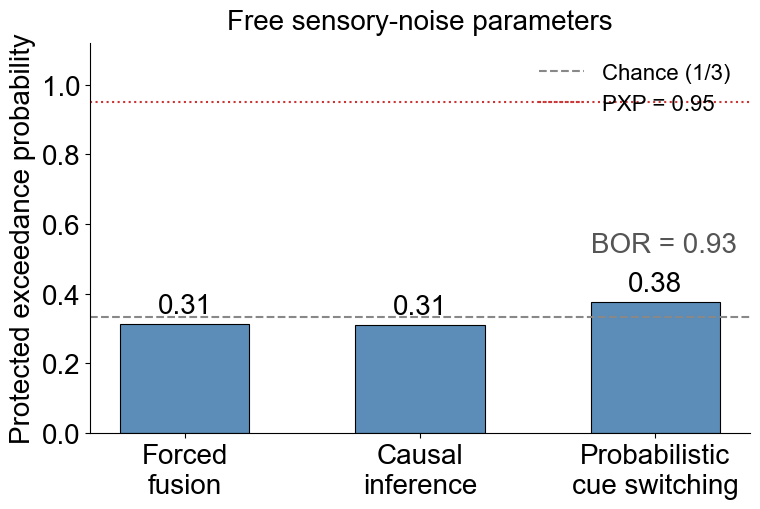

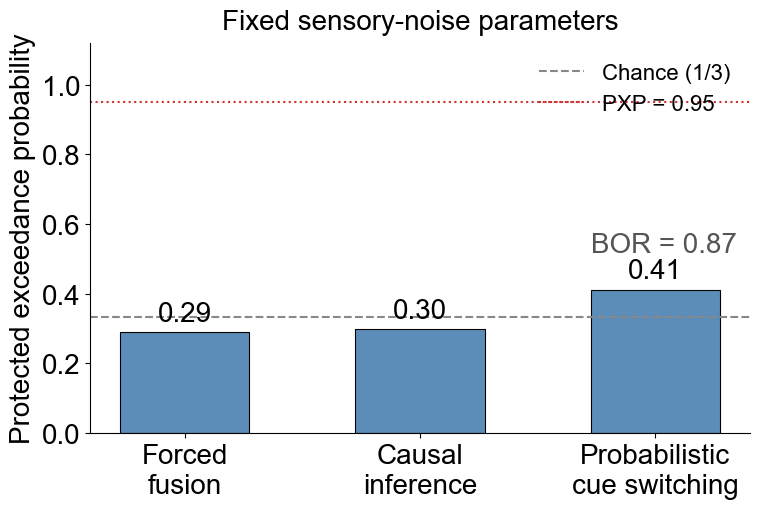

In [22]:
def plot_pxp(bms_result, title_suffix='', save_path=None):
    plt.rcParams.update({
        'font.size': 20, 'font.weight': 'normal',
        'axes.labelweight': 'normal', 'axes.titleweight': 'normal',
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    })
    K = len(bms_result['models'])
    pxp = bms_result['pxp']
    short = [m.replace(' ', '\n', 1) for m in bms_result['models']]

    fig, ax = plt.subplots(figsize=(8, 5.5))
    bars = ax.bar(np.arange(K), pxp, width=0.55, color='#5b8db8',
                  edgecolor='black', linewidth=0.8)
    ax.axhline(1 / K, color='#888888', linestyle='--', linewidth=1.5, label=f'Chance (1/{K})')
    ax.axhline(0.95, color='#cc3333', linestyle=':', linewidth=1.5, label='PXP = 0.95')
    for bar, val in zip(bars, pxp):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=20)
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels(short, fontsize=20)
    ax.set_ylabel('Protected exceedance probability', fontsize=20)
    ax.set_ylim(0, 1.12)
    ax.tick_params(axis='y', labelsize=20)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.text(0.98, 0.45, f"BOR = {bms_result['bor']:.2f}", transform=ax.transAxes,
            ha='right', va='bottom', fontsize=20, color='#555555')
    if title_suffix:
        ax.set_title(title_suffix, fontsize=20, pad=10)
    ax.legend(fontsize=16, frameon=False, loc='upper right')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=900, bbox_inches='tight')
        plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()


plot_pxp(bms_free, title_suffix='Free sensory-noise parameters',
         save_path='pxp_threeModels_freeSigma.pdf')
plot_pxp(bms_uni, title_suffix='Fixed sensory-noise parameters',
         save_path='pxp_threeModels_unimodalSigma.pdf')